
<font size = "5"> **Day 3: [Spectroscopic Data & ML‑Enabled Analysis](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />



[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day%203/11AM_Analyze_LowLoss_EELS.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%203/11AM_Analyze_LowLoss_EELS.ipynb)


# Analysing Low-Loss Spectra with Drude Theory
part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day3: Spectroscopic Data & ML‑Enabled Analysis**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**


## Content
Analyse EELS spectra and spectrum images.This works also on Google Colab.


## Prerequesites

### Install pyTEMlib

If you have not done so in the [Introduction Notebook](_.ipynb), please test and install [pyTEMlib](https://github.com/gduscher/pyTEMlib) and other important packages with the code cell below.





## Content
The main feature in a low-loss EELS spectrum is the ``volume plasmon`` peak.

This ``volume plasmon`` and all other features in the ``low-loss`` region of an EELS spectrum are described by the Dielectric Theory of Electrodynamics.

The simplest theory to interprete this energy range is the Drude theory. 

Another easy to observe component of the Low-Loss Spectrum is the multiple scattering of this plasmon peak, which we can correct for or use for thickness determination.

>See [Notebook: Analysing Low-Loss Spectra with Drude Theory](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM/main/Spectroscopy/CH4_03-Drude.ipynb) of the MSE672-Introduction-to-TEM Lecture in my Github account.


## Load important packages

### Check Installed Packages


In [1]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install --upgrade git+https://github.com/pycroscopy/pyTEMlib.git@main -q --upgrade
# ------------------------------
print('done')

done


### Import all relevant libraries

Please note that the EELS_tools package from pyTEMlib is essential.

In [1]:
%matplotlib widget
import sys
import os

import matplotlib.pyplot as plt 
import numpy as np

if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    from google.colab import drive

# Import libraries from pyTEMlib
import pyTEMlib

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)

pyTEM version:  0.2026.6.0


## Load and plot a spectrum

In [2]:
if 'google.colab' in sys.modules:
    #drive.mount("/content/drive")
    if not os.path.exists('./CBED_375mm_alpha-3.3_beta9.6_Condensor10um_Filter.dm3'):
        !wget  https://github.com/gduscher/MLSTEM2025//raw/main/example_data/Day%203/example_data/AL-DFoffset0.00.dm3
        
file_widget = pyTEMlib.file_tools.FileWidget()

experiment :
	single_exposure_time : 4.999237616263519e-05
	exposure_time : 0.005390757616263521
	number_of_frames : 3961
	convergence_angle : 30
	collection_angle : 40
	microscope : Unknown
	acceleration_voltage : 60000.0
filename : c:\Users\gduscher\OneDrive - University of Tennessee\2026 Experiments\2026-06-09-Si\EELS LL_0719.dm4


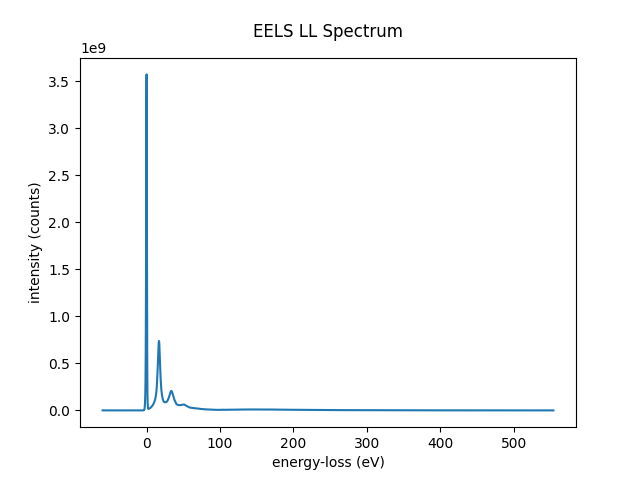

In [5]:
spectrum = file_widget.selected_dataset
spectrum.metadata['experiment']['convergence_angle'] = 30
spectrum.metadata['experiment']['collection_angle'] = 40

view = spectrum.plot()
spectrum.view_metadata()

## Align Energy Scale
### Shift maximum of zero-loss peak to origin of energy axis

shifted zero loss: [-0.13682425]


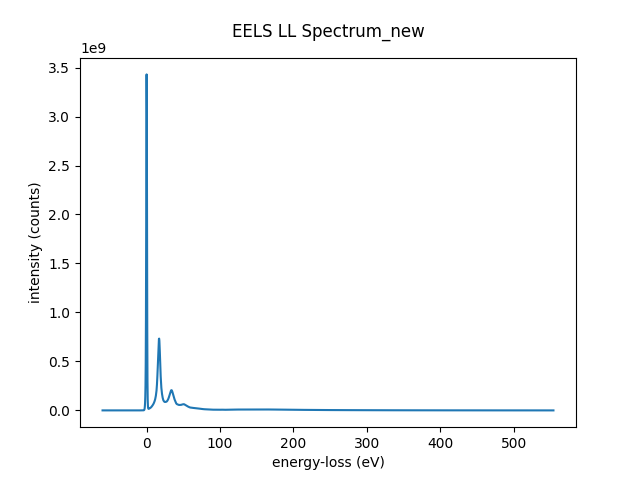

In [7]:
shifted_low_loss = pyTEMlib.eels_tools.align_zero_loss(file_widget.selected_dataset)
plt.close('all')
view = shifted_low_loss.plot()
print(f"shifted zero loss: {shifted_low_loss.metadata['zero_loss']['shifted']}")


## Fit Zero Loss Peak
Fit zero-loss peak with a product of two lorentzians.

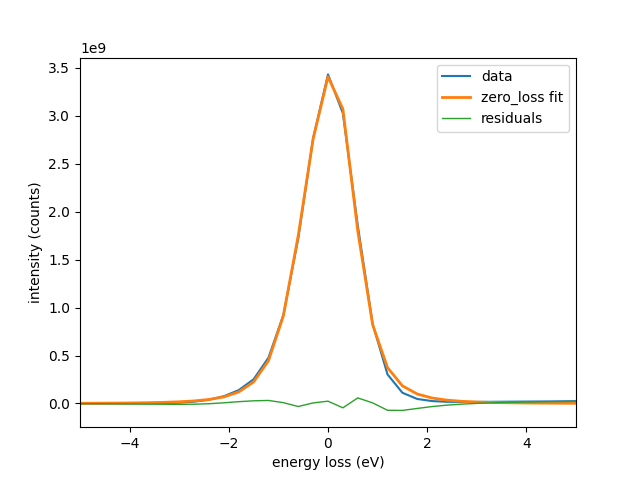

In [8]:
zero_loss = pyTEMlib.eels_tools.get_resolution_function(shifted_low_loss)
(shifted_low_loss)
plt.figure()
plt.plot(shifted_low_loss.energy_loss, shifted_low_loss, label="data")
plt.plot(shifted_low_loss.energy_loss, zero_loss, label="zero_loss fit", linewidth=2)
plt.plot(shifted_low_loss.energy_loss, shifted_low_loss-zero_loss, label="residuals", linewidth=1)
plt.legend()
plt.xlabel("energy loss (eV)")
plt.ylabel("intensity (counts)")
plt.xlim(-5, 5);

The fit_parameters of the zero-loss peak are stored in the metadata

In [9]:
shifted_low_loss.view_metadata()

experiment :
	single_exposure_time : 4.999237616263519e-05
	exposure_time : 0.005390757616263521
	number_of_frames : 3961
	convergence_angle : 30
	collection_angle : 40
	microscope : Unknown
	acceleration_voltage : 60000.0
filename : c:\Users\gduscher\OneDrive - University of Tennessee\2026 Experiments\2026-06-09-Si\EELS LL_0719.dm4
zero_loss :
	shifted : [-0.13682425]
	fit :
		parameters : [ 3.37384810e-01  7.11937237e+04  1.23578803e+00 -4.66143805e-01
  8.08454794e+04  1.59049825e+00]
		function : product of lorentzians


## Fit Plasmon Peak
We fit the plasmon peak with a Drude Lorentz function of the dielectric function eps
and then we calculate the loss function from that.

### Fitting Single Scattering 

The single scattering intensity $J_1$ (and that is what we want to fit) is defined according to Egerton (ed.:3, equ.:4.26)
$$ J_1 = \frac{I_0t}{\pi a_0 m_0 v^2} \Im \left[\frac{-1}{\varepsilon(E)} \right]\ln \left[1+\left( \frac{\beta}{\theta_E}\right)^2 \right]$$
The logartyhmic term at the end is energy depedent because of the characteristic angle $\theta_E$ ($\theta_E = E/(\gamma m_0v^2)$) and must be considered if we want to deive the dielectric function.
This angular dependence is:

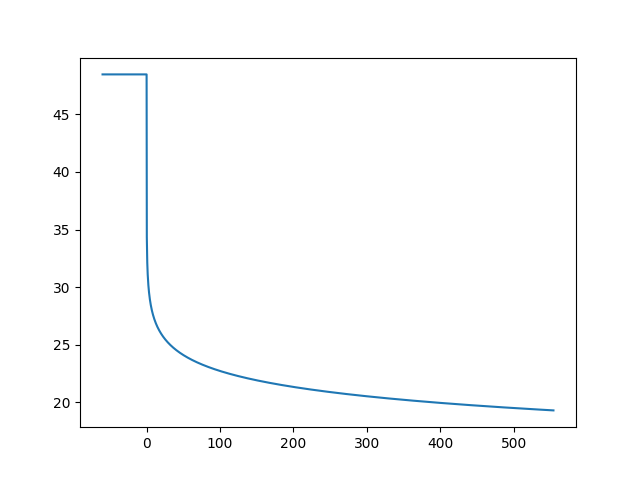

In [10]:

def get_anglog(energy_scale, acceleration_voltage, beta):
    e0 = acceleration_voltage/1000
    gamma = 1+ e0/511.06
    T = e0 * (e0 + 1022.12)/ (e0 + 511.06) # Appendix E p 427 in keV
    theta_E = energy_scale/(2*gamma*T*1000)   # Appendix E p 427 now in eV

    theta_E[np.where(theta_E<=0)] = 1e-9
    return np.log(1.0+ (beta/theta_E)**2)
   

acceleration_voltage = spectrum.metadata['experiment']['acceleration_voltage']*1
energy_scale = spectrum.get_spectral_dims(return_axis=True)[0].values
eff_beta = pyTEMlib.eels_tools.effective_collection_angle(energy_scale,
                                                              spectrum.metadata['experiment']['convergence_angle'],
                                           spectrum.metadata['experiment']['collection_angle'],
                                           acceleration_voltage)
anglog = pyTEMlib.eels_tools.get_anglog(energy_scale, acceleration_voltage, eff_beta)
plt.figure()
plt.plot(spectrum.energy_loss.values, anglog)

In [11]:
import scipy
# -----Input ------------
start_fit_energy = 13
end_fit_energy = 20
# ----------------------

plasmon, fit_p= pyTEMlib.eels_tools.fit_plasmon(shifted_low_loss, start_fit_energy, end_fit_energy)

plasmon = energy_loss_function(shifted_low_loss.energy_loss.values, fit_p, anglog)
plt.figure()
plt.plot(shifted_low_loss.energy_loss.values, shifted_low_loss, label="data")
plt.plot(shifted_low_loss.energy_loss.values, plasmon, label="Drude_fit")
plt.plot(shifted_low_loss.energy_loss.values, zero_loss, label="zero_loss", linewidth=1)
plt.plot(shifted_low_loss.energy_loss.values, shifted_low_loss-plasmon-zero_loss, label="residuals", linewidth=1)
plt.legend()
shifted_low_loss.metadata

200 244 267


NameError: name 'energy_loss_function' is not defined

(-10.0, 10.0)

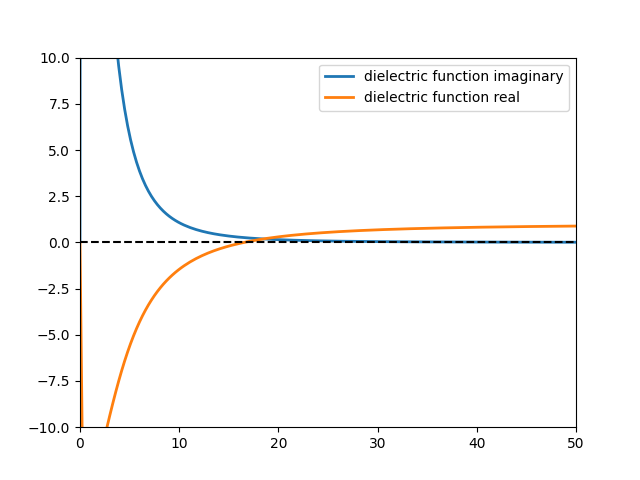

In [12]:

epsilon = pyTEMlib.eels_tools.drude(shifted_low_loss.energy_loss.values, fit_p)

plt.figure()
plt.plot(shifted_low_loss.energy_loss, epsilon.imag, label="dielectric function imaginary", linewidth=2)
plt.plot(shifted_low_loss.energy_loss, epsilon.real, label="dielectric function real", linewidth=2)
plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.xlim(0, 50)
plt.ylim(-10, 10)

### Fitting Multiple Scattering
The multiple scattering of the plasmon peak is a convolution of several orders of the single scattering plasmon peak

The relative intensity of the convoluted plasmon peak of order *n* $P_n$ is dependent on the relative thickness ($t/\lambda$) as according to Edgerton (ed.: 3, equ.: 3.94):

$$P_n = \frac{I_n}{I_0} = \frac{1}{n!} \left(\frac{t}{\lambda}\right)^n \exp\left(\frac{-t}{\lambda}\right)$$




{'experiment': {'single_exposure_time': 4.999237616263519e-05,
  'exposure_time': 0.005390757616263521,
  'number_of_frames': 3961,
  'convergence_angle': 30,
  'collection_angle': 40,
  'microscope': 'Unknown',
  'acceleration_voltage': 60000.0},
 'filename': 'c:\\Users\\gduscher\\OneDrive - University of Tennessee\\2026 Experiments\\2026-06-09-Si\\EELS LL_0719.dm4',
 'zero_loss': {'shifted': array([-0.13682425]),
  'fit': {'parameters': array([ 3.37384810e-01,  7.11937237e+04,  1.23578803e+00, -4.66143805e-01,
           8.08454794e+04,  1.59049825e+00]),
   'function': 'product of lorentzians'}},
 'plasmon': {'single_scattering_fit': {'parameters': array([ 1.71026184e+01, -9.59680022e-02,  2.19323481e+00,  7.09355900e+06]),
   'fit_range': (13, 20),
   'function': 'Drude'},
  'multiple_scattering_fit': {'parameters': array([1.70790907e+01, 9.17201659e-02, 2.02767244e+00, 6.72353216e+06,
          9.71317972e-01]),
   'tmfp': np.float64(0.9713179722510744)}}}

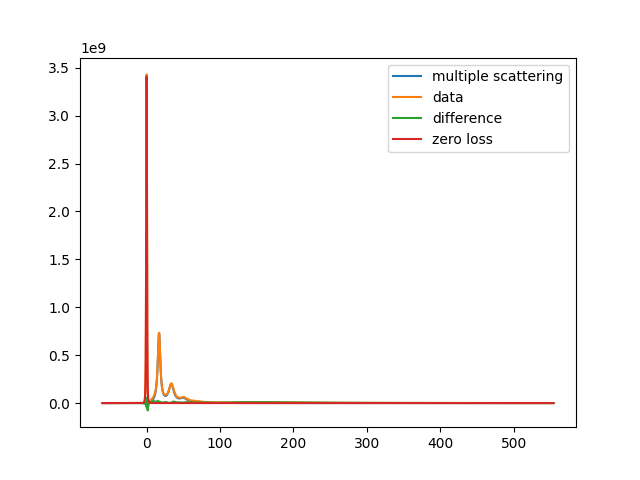

In [13]:
multiple_scattering = pyTEMlib.eels_tools.fit_multiple_scattering(shifted_low_loss-zero_loss, anglog, end_fit_energy=55, )   

plt.figure()
plt.plot(energy_scale, multiple_scattering, label="multiple scattering")
plt.plot(energy_scale, shifted_low_loss, label="data")
plt.plot(energy_scale, shifted_low_loss - multiple_scattering - zero_loss, label="difference")
plt.plot(energy_scale, zero_loss, label="zero loss")
plt.legend()
shifted_low_loss.metadata



In [14]:

_,_ = pyTEMlib.eels_tools.estimate_thickness(shifted_low_loss, anglog)


Volume-plasmon MFP = 5.46 nm
Free-electron MFP = 56.45 nm
--------------------------------
relative thickness t/lambda: 0.971
estimated thickness = 54.84 nm



## Peakfit
Of course, one can also just fit a lot of Gaussians to the spectrum.

This will give us a good approximation of a noise free spectrum

using 27 Gaussians for fit


c:\Users\gduscher\OneDrive - University of Tennessee\GitHub\pyTEMlib\notebooks\Spectroscopy\../..\pyTEMlib\eels_tools\peak_fit_tools.py:186: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  [p, _] = scipy.optimize.leastsq(residuals3, pin, args=(x, y),maxfev = 10000)


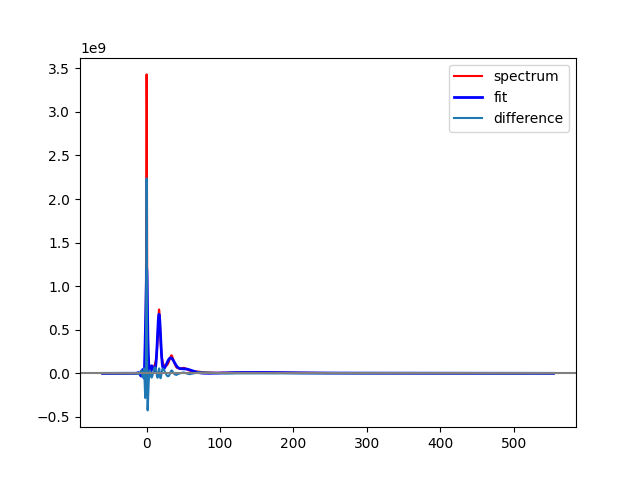

In [15]:
spectrum = shifted_low_loss
energy_scale = spectrum.energy_loss
peak_model, p = pyTEMlib.eels_tools.gaussian_mixture_model(spectrum, p_in=None)

print(f'using {int(len(p)/3)} Gaussians for fit')

plt.figure()

plt.plot(energy_scale, spectrum, c='red', label='spectrum')
plt.plot(energy_scale, peak_model, linewidth=2, c='blue',  label='fit')
plt.plot(energy_scale, spectrum-peak_model, label='difference')
plt.axhline(0, c='gray')
plt.legend();

### Using above fits
With the above fits of zero-loss peak and multiple scattering fo plasmons
we have already a good approximation. Which we can use to refine

using 30 Gaussians for fit


c:\Users\gduscher\OneDrive - University of Tennessee\GitHub\pyTEMlib\notebooks\Spectroscopy\../..\pyTEMlib\eels_tools\peak_fit_tools.py:186: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  [p, _] = scipy.optimize.leastsq(residuals3, pin, args=(x, y),maxfev = 10000)


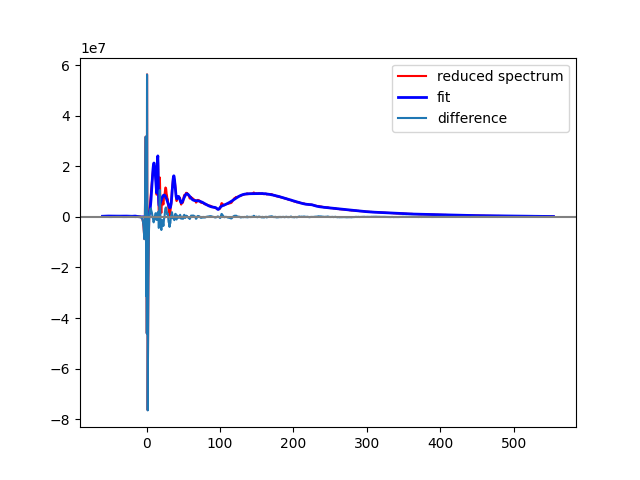

In [16]:

spectrum = shifted_low_loss-zero_loss-multiple_scattering
energy_scale = spectrum.energy_loss
peak_model, p = pyTEMlib.eels_tools.gaussian_mixture_model(spectrum, p_in=None)

print(f'using {int(len(p)/3)} Gaussians for fit')

plt.figure()

plt.plot(energy_scale, spectrum, c='red', label='reduced spectrum')
plt.plot(energy_scale, peak_model, linewidth=2, c='blue',  label='fit')
plt.plot(energy_scale, spectrum-peak_model, label='difference')
plt.axhline(0, c='gray')
plt.legend();

The additional intensity contains information like the core-loss edge (here Si-L2,3 at 99.8 eV), retardation effects and interband transitions.
The fit improves a lot and we get a very good noise free approximation of the spectrum.

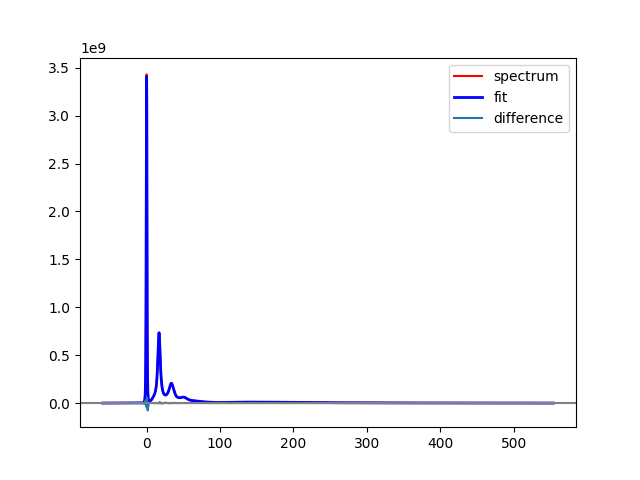

In [17]:
spectrum = shifted_low_loss
subtracted = zero_loss+multiple_scattering
energy_scale = spectrum.energy_loss

plt.figure()

plt.plot(energy_scale, spectrum, c='red', label='spectrum')
plt.plot(energy_scale, peak_model+subtracted, linewidth=2, c='blue',  label='fit')
plt.plot(energy_scale, spectrum-peak_model-subtracted, label='difference')
plt.axhline(0, c='gray')
plt.legend();


## Summary

The beauty of ``Low-Loss spectroscopy`` is its derivation of the dielectric function to high energies without prior knowledge of the composition. The signal is strong and the acquisition time is mostly restricted by the dynamic range of the spectrum.


**Think of low-loss spectroscopy as Electrodynamics**

The advantages of EELS is the derivation of these values spatially resolved.
And from a linescan across an Si/SiO$_2$ interface the dielectric function per pixel can be obtained. From that we can calculate the dielectric polarizability $\alpha_e (E)$, which may be  a measure of the dielectric strength.


We obtain more or less easily:
- relative thickness
- absolute thickness 
- inelastic mean free path
- plasmon frequency
- plasmon width
- band gap
- dielectric function
- reflectivity 
- absorption
- effective number of electrons per atoms 
 


The analysis of the optical data requires the exact knowledge of the zero-loss peak. Because of the weighting in the Fourier Analysis, the low energy part contributes heavily to the dielectric function. Therefore, energy resolution is critical for an exact determination of all the optical values from EELS. The new monochromated TEMs are now able to achieve an energy resolution of 10 meV (one is at the oak Ridge National Laboratory), which allows for a sharper zero-loss peak. Such a sharp zero-loss peak will enable us to extract this low energy data more accurately. The dielectric function and the parameters derived from it, can be more precisely determined from such EELS spectra.


## Appendix 


In [ ]:
import scipy

def drude(energy_scale: np.ndarray, parameters: list) -> np.ndarray:
    """dielectric function according to Drude theory"""
    peak_position, peak_width, gamma = parameters[:3]
    if energy_scale[0] < 0:
        zero_pixel = np.searchsorted(energy_scale, 0)+1
    else:
        zero_pixel = 0
    energy_eps = energy_scale[zero_pixel:]
    eps = (1 - (peak_position ** 2 - peak_width * energy_eps * 1j) /
           (energy_eps ** 2 + 2 * energy_eps * gamma * 1j))  # Mod drude term
    out_array = np.zeros(len(energy_scale), dtype=complex)
    out_array[zero_pixel:] = eps
    return out_array

def energy_loss_function(energy: np.ndarray, p: np.ndarray, anglog=1) -> np.ndarray:
    """Energy loss function based on dielectric function."""
    # eps = 1 - p[0]**2/(energy**2+p[1]**2) + 1j * p[1] * p[0]**2/energy/(energy**2+p[1]**2)
    eps = drude(energy, p)
    eps[eps==0.0]= 1e-19
    elf = (-1/eps).imag
    return elf*p[3] * anglog


def fit_plasmon(spectrum, start_fit_energy, end_fit_energy):
    energy = spectrum.get_spectral_dims(return_axis=True)[0].values

    start_fit_pixel = np.searchsorted(energy, start_fit_energy)
    end_fit_pixel = np.searchsorted(energy, end_fit_energy)
    zero_pixel = np.searchsorted(energy, 0)
    print(zero_pixel, start_fit_pixel, end_fit_pixel)
    acceleration_eV = spectrum.metadata['experiment']['acceleration_voltage']
    convergence_angle = spectrum.metadata['experiment']['convergence_angle']

    anglog = get_anglog(energy[start_fit_pixel:end_fit_pixel], acceleration_eV, convergence_angle)
    def residuals(parameters, energy, data):
        return data - energy_loss_function(energy, parameters, anglog)

    guess = np.array([start_fit_energy+(end_fit_energy-start_fit_energy)/2, 4, 1.1, 1000])
    fit_p = scipy.optimize.least_squares(residuals, guess, args=(energy[start_fit_pixel:end_fit_pixel],
                                                                 np.array(spectrum)[start_fit_pixel:end_fit_pixel]),
                                                                 method='lm')
    
    anglog = get_anglog(energy, acceleration_eV, convergence_angle)
    
    low_loss = energy_loss_function(energy, fit_p['x'], anglog)
    low_loss[: zero_pixel] = 0.0
    spectrum.metadata.setdefault('plasmon', {}).['fit']={'parameters': fit_p['x'],
                                                         'fit_range': (start_fit_energy, end_fit_energy),
                                                         'function': 'Drude'})
    return low_loss, fit_p['x']


In [ ]:


def multiple_scattering(energy_scale: np.ndarray, p, anglog )-> np.ndarray:
    tmfp = p[4]
    if energy_scale[0] < 0:
        zero_pixel = np.searchsorted(energy_scale, 0)+1
    else:
        zero_pixel = 0
    
    SSD = energy_loss_function(energy_scale, p, anglog)[zero_pixel:]
    ssd  = np.fft.fft(SSD)
    ssd2 = ssd.copy()
    
    ### sum contribution from each order of scattering:
    PSD = np.zeros(len(energy_scale[zero_pixel:]))
    for order in range(15):
        # This order convoluted spectum 
        # convoluted SSD is SSD2
        SSD2 = np.fft.ifft(ssd).real
    
        # And add this order to final spectrum #using equation 4.1 of egerton 2nd edition
        PSD += (SSD2*abs(sum(SSD)/sum(SSD2)) 
                / scipy.special.factorial(order+1)
                * np.power(tmfp, (order+1)) * np.exp(-tmfp))
        
        # next order convolution
        ssd = ssd * ssd2
    
    PSD /=tmfp*np.exp(-tmfp)
    msd = np.zeros(len(energy_scale))
    msd[zero_pixel:] = PSD
    return msd

def fit_multiple_scattering(spectrum, anglog, end_fit_energy=55):
    """
    Fit multiple scattering of plasmon peak in a TEM dataset.
    """
    energy_scale = spectrum.energy_loss.values
    p0 = list(spectrum.metadata['plasmon']['single_scattering_fit']['parameters'])+[.5]
    
    def errf_multi(p, y, x):
        elf = multiple_scattering(x, p, anglog[:endFit])
        return np.abs(y - elf)  # /np.sqrt(y)
    endFit = np.searchsorted(energy_scale, end_fit_energy)

    p2 = scipy.optimize.least_squares(errf_multi,
                                      p0,
                                      args=(np.array(spectrum)[:endFit],
                                            energy_scale[:endFit]),
                                      method='lm')
    p2 = p2['x']

    cts = multiple_scattering(energy_scale, p2, anglog)
    print(f"relative thickness t/lambda: {p2[4]:.3f}")
    spectrum.metadata['multiple_scattering_fit'] = {'parameters': p[:3],
                                                    'tmfp': p[:4]}
    return cts

In [ ]:
def estimate_thickness(spectrum, anglog):
    energy_scale = spectrum.get_spectral_dims(return_axis=True)[0].values
    p2 = spectrum.metadata['plasmon']['multiple_scattering_fit']['parameters']
    
    eps = drude(energy_scale, p2)
    eps[eps==0.0]= 1e-19
    elf = (-1/eps).imag * anglog* p2[3]
    e0 = spectrum.metadata['experiment']['acceleration_voltage']/1000
    beta = spectrum.metadata['experiment']['collection_angle']/1000
    T = 1000.0*e0*(1.+e0/1022.12)/(1.0+e0/511.06)**2;# %eV # equ.5.2a or Appendix E p 427 
    
    tnm = spectrum.metadata['plasmon']['multiple_scattering_fit']['parameters'][4]
    print(tnm)
    volint = abs(tnm/(np.pi*0.05292*T*2.0)*elf*anglog)
    Pv = (volint/shifted_low_loss).sum() ## our data have he same epc and the trapz formula does not include 
    ep = p2[0]
    tgt = 1000*e0*(1022.12 + e0)/(511.06 + e0);# %eV  Appendix E p 427 
    lambda_pv = tnm/Pv; #% does NOT depend on free-electron approximation (no damping). 
    lambda_fe = 4.0*0.05292*T/ep/np.log(1+(beta* tgt / ep) **2); #% Eq.(3.44) approximation

    print(f'Volume-plasmon MFP = {lambda_pv:.2f} nm') 
    print(f'Free-electron MFP = {lambda_fe:.2f} nm')
    print('--------------------------------')
    print(f"relative thickness t/lambda: {tnm:.3f}")
    print(f'estimated thickness = {lambda_fe*tnm:.2f} nm\n')
    return lambda_pv, lambda_fe, elf